In [1]:
import json
from pathlib import Path

import pandas as pd


RESULTS_ROOT = Path("../results")


# --------------------------------------------------
# run 자동 탐색
# --------------------------------------------------
def discover_runs(results_root: Path):
    runs = []
    

    for traj_path in results_root.rglob("trajectory_logs.jsonl"):
        parts = traj_path.parent.relative_to(results_root).parts

        if len(parts) < 3:
            continue

        model, dataset, strategy = parts[:3]
        
        

        runs.append({
            "model": model,
            "dataset": dataset,
            "strategy": strategy,
            "trajectory_path": traj_path,
        })

    return runs


# --------------------------------------------------
# trajectory_logs.jsonl 읽기
# --------------------------------------------------
def read_jsonl(path):
    rows = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line:
                rows.append(json.loads(line))

    return rows


# --------------------------------------------------
# Success@k 계산
# --------------------------------------------------
def compute_success_curve(rows, max_k=20):
    total = len(rows)

    table = []

    for k in range(1, max_k + 1):

        solved = sum(
            1
            for r in rows
            if r["final_status"] == "PASS"
            and r["call_count"] <= k
        )

        success_rate = solved / total * 100

        table.append({
            "k": k,
            "success_rate": success_rate,
        })

    return pd.DataFrame(table)


# --------------------------------------------------
# 전략 이름 pretty mapping
# --------------------------------------------------
STRATEGY_NAME_MAP = {
    "single_shot": "Single-shot",
    "repair_loop": "Repair",
    "code_then_plan": "Planning",
    "code_then_plan_repair": "Planning-Repair",
}


# --------------------------------------------------
# HumanEval + qwen25coder7b 필터
# --------------------------------------------------
runs = discover_runs(RESULTS_ROOT)

filtered_runs = [
    r for r in runs
    if r["dataset"] == "humaneval"
    and "qwen25coder7b" in r["model"] and not "proposed_v1" in r["strategy"] and not "proposed_v2" in r["strategy"]
]

print(f"Filtered runs: {len(filtered_runs)}")


# --------------------------------------------------
# 전략별 Success@k 생성
# --------------------------------------------------
merged = None

for run in filtered_runs:

    rows = read_jsonl(run["trajectory_path"])

    curve_df = compute_success_curve(rows)

    strategy_key = run["strategy"]

    pretty_name = STRATEGY_NAME_MAP.get(
        strategy_key,
        strategy_key
    )

    curve_df = curve_df.rename(
        columns={
            "success_rate": pretty_name
        }
    )

    if merged is None:
        merged = curve_df

    else:
        merged = merged.merge(curve_df, on="k")


# --------------------------------------------------
# 퍼센트 formatting
# --------------------------------------------------
display_df = merged.copy()

for col in display_df.columns:
    if col != "k":
        display_df[col] = display_df[col].map(
            lambda x: f"{x:.1f}%"
        )


# --------------------------------------------------
# 출력
# --------------------------------------------------
print("\nSuccess@k Recovery Table\n")
print(display_df)


# --------------------------------------------------
# CSV 저장
# --------------------------------------------------
output_path = Path("./archive/success_at_k_table.csv")

merged.to_csv(output_path, index=False)

print(f"\nSaved CSV to: {output_path}")

Filtered runs: 4

Success@k Recovery Table

     k single repair Planning Planning-Repair
0    1  70.7%  68.9%    70.7%           70.1%
1    2  70.7%  74.4%    70.7%           70.1%
2    3  70.7%  80.5%    89.0%           87.8%
3    4  70.7%  81.7%    89.0%           89.0%
4    5  70.7%  83.5%    89.6%           89.0%
5    6  70.7%  83.5%    89.6%           92.1%
6    7  70.7%  83.5%    91.5%           92.1%
7    8  70.7%  83.5%    91.5%           92.1%
8    9  70.7%  83.5%    91.5%           92.1%
9   10  70.7%  83.5%    91.5%           92.1%
10  11  70.7%  83.5%    91.5%           92.1%
11  12  70.7%  83.5%    91.5%           92.1%
12  13  70.7%  83.5%    92.1%           92.1%
13  14  70.7%  84.1%    92.1%           92.1%
14  15  70.7%  84.1%    92.1%           92.1%
15  16  70.7%  84.1%    92.1%           92.1%
16  17  70.7%  84.1%    92.1%           92.1%
17  18  70.7%  84.1%    92.1%           92.1%
18  19  70.7%  84.1%    92.7%           92.1%
19  20  70.7%  84.1%    92.7%       

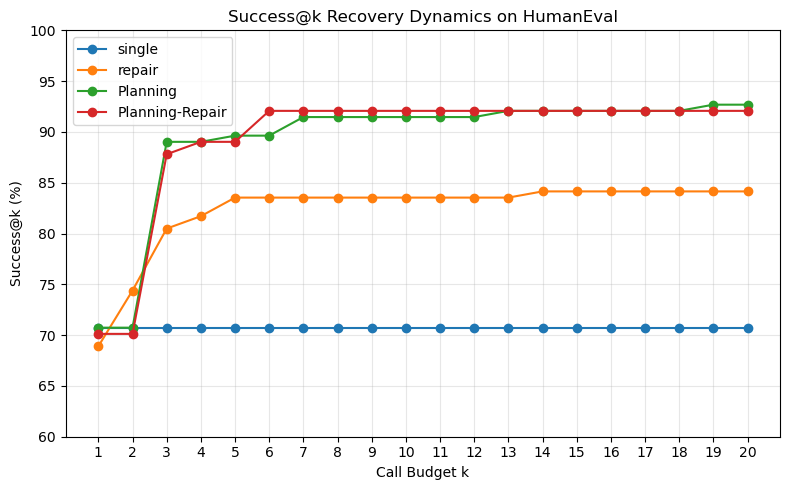

<Figure size 640x480 with 0 Axes>

In [2]:
import matplotlib.pyplot as plt

plot_df = merged.copy()

plt.figure(figsize=(8, 5))

for col in plot_df.columns:
    if col != "k":
        plt.plot(
            plot_df["k"],
            plot_df[col],
            marker="o",
            label=col
        )

plt.xlabel("Call Budget k")
plt.ylabel("Success@k (%)")
plt.title("Success@k Recovery Dynamics on HumanEval")
plt.xticks(range(1, 21))
plt.ylim(60, 100)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()
plt.savefig("./archive/success_at_k_recovery_curve.png", dpi=300)
